<a href="https://colab.research.google.com/github/elizaveta-p/academic-risk-prediction-oulad/blob/main/student_performance_prediction_oulad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогнозирование академического риска студентов

In [ ]:
import pandas as pd
import numpy as np

## 1. Обзор проекта и описание данных

**Бизнес-проблема:** Раннее выявление студентов, находящихся в зоне академического риска (тех, кто может провалить курс или отказаться от обучения), имеет решающее значение для образовательных учреждений. Это позволяет своевременно применять поддерживающие меры, повышая успеваемость студентов и снижая отток.

**Цель проекта:** Разработка модели бинарной классификации для прогнозирования академического риска студентов на основе данных об их демографии, успеваемости и активности в системе управления обучением (LMS).

**Используемый стек:** Python, pandas, NumPy, scikit-learn, matplotlib, seaborn.

**Методы:** data cleaning, table joins, feature engineering, EDA, binary classification, model evaluation, feature importance/interpretability.

**Описание данных:** Датасет OULAD (Open University Learning Analytics Dataset) содержит информацию о студентах, их взаимодействии с учебными материалами онлайн-курсов, оценках и результатах обучения.

Для воспроизведения этого проекта необходимо скачать датасет `student-demographics-online-education-dataoulad.zip` с платформы Kaggle (https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad) и поместить его в рабочую директорию или указать путь к нему.

Для скачивания данных с Kaggle требуется `kaggle.json`. Этот файл должен быть размещен в `~/.kaggle/` и иметь права `600`. В рамках данного проекта предполагается, что датасет уже скачан и разархивирован.

In [ ]:
!unzip -o student-demographics-online-education-dataoulad.zip -d oulad_data

Archive:  student-demographics-online-education-dataoulad.zip
  inflating: oulad_data/assessments.csv  
  inflating: oulad_data/courses.csv  
  inflating: oulad_data/studentAssessment.csv  
  inflating: oulad_data/studentInfo.csv  
  inflating: oulad_data/studentRegistration.csv  
  inflating: oulad_data/studentVle.csv  
  inflating: oulad_data/vle.csv      


In [ ]:
import os

print(os.listdir("oulad_data"))

['assessments.csv', 'studentRegistration.csv', 'studentAssessment.csv', 'courses.csv', 'studentVle.csv', 'vle.csv', 'studentInfo.csv']


## 2. Первичный обзор данных и загрузка

In [ ]:
data_path = "oulad_data"

courses = pd.read_csv(f"{data_path}/courses.csv")
student_info = pd.read_csv(f"{data_path}/studentInfo.csv")
student_assessment = pd.read_csv(f"{data_path}/studentAssessment.csv")
student_registration = pd.read_csv(f"{data_path}/studentRegistration.csv")
student_vle = pd.read_csv(f"{data_path}/studentVle.csv")
assessments = pd.read_csv(f"{data_path}/assessments.csv")
vle = pd.read_csv(f"{data_path}/vle.csv")

In [ ]:
tables = {
    "studentInfo": student_info,
    "studentAssessment": student_assessment,
    "studentVle": student_vle,
    "studentRegistration": student_registration,
    "courses": courses,
    "assessments": assessments,
    "vle": vle
}

for name, df in tables.items():
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    display(df.head())


===== studentInfo =====
Shape: (32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



===== studentAssessment =====
Shape: (173912, 5)


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0



===== studentVle =====
Shape: (10655280, 6)


...

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240



===== assessments =====
Shape: (206, 6)


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0



===== vle =====
Shape: (6364, 6)


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


## 3. Определение целевой переменной

Целевая переменная 'final_result' в исходных данных имеет несколько категорий.

In [ ]:
tables['studentInfo']['final_result'].unique()

array(['Pass', 'Withdrawn', 'Fail', 'Distinction'], dtype=object)

In [ ]:
for name, df in tables.items():
    print(f"\n===== {name} =====")
    print(df.info())


===== studentInfo =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB
None

===== studentAssessment =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Da

In [ ]:
for name, df in tables.items():
    print(f"\n===== {name} =====")
    print(df.isna().sum())


===== studentInfo =====
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

===== studentAssessment =====
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

===== studentVle =====
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

===== studentRegistration =====
code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

===== courses =====
code_module                   0
code_presentation             0
module_pr

In [ ]:
student_info['final_result'].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


### 3.1. Трансформация целевой переменной

Для задачи бинарной классификации академического риска создается новая целевая переменная `at_risk`:

- `at_risk = 1` для студентов, получивших 'Fail' (провал) или 'Withdrawn' (отчисление).
- `at_risk = 0` для студентов, получивших 'Pass' (успешно) или 'Distinction' (отлично).

In [ ]:
student_info['at_risk'] = student_info['final_result'].map({
    'Pass': 0,
    'Distinction': 0,
    'Fail': 1,
    'Withdrawn': 1
})

In [ ]:
student_info['at_risk'].value_counts()

,count
at_risk,
1,17208
0,15385


In [ ]:
student_registration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [ ]:
student_registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
student_registration.isna().sum()

,0
code_module,0
code_presentation,0
id_student,0
date_registration,45
date_unregistration,22521


## 4. Подготовка данных и генерация признаков

На данном этапе таблицы объединяются для создания единого базового датасета, включающего информацию о студентах, их регистрации и результатах оценивания.

In [ ]:
registration_features = student_registration[
    ['code_module', 'code_presentation', 'id_student', 'date_registration']
].copy()

registration_features = registration_features.dropna(subset=['date_registration'])

base_df = student_info.merge(
    registration_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='inner'
)

### 4.1. Объединение базовой информации о студентах

Проверка структуры и первых строк объединенного датасета.

In [ ]:
print(base_df.shape)
base_df.head()

(32548, 14)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk,date_registration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,-159.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,-53.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,-92.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,-52.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,-176.0


### 4.2. Объединение данных об оцениваниях

Объединение таблиц, связанных с оцениванием, для последующей генерации признаков.

In [ ]:
assessment_full = student_assessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

print(assessment_full.shape)
assessment_full.head()

(173912, 10)


,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0


### 4.3. Генерация признаков на основе оценивания

Агрегируются данные об оцениваниях для формирования признаков, характеризующих учебную активность и успеваемость студентов.

In [ ]:
assessment_features = (
    assessment_full
    .groupby(['code_module', 'code_presentation', 'id_student'])
    .agg(
        assessments_count=('id_assessment', 'count'),
        score_mean=('score', 'mean'),
        score_median=('score', 'median'),
        score_max=('score', 'max'),
        score_min=('score', 'min'),
        banked_share=('is_banked', 'mean')
    )
    .reset_index()
)

print(assessment_features.shape)
assessment_features.head()

(25843, 9)


,code_module,code_presentation,id_student,assessments_count,score_mean,score_median,score_max,score_min,banked_share
0,AAA,2013J,11391,5,82.0,82.0,85.0,78.0,0.0
1,AAA,2013J,28400,5,66.4,68.0,70.0,60.0,0.0
2,AAA,2013J,31604,5,76.0,74.0,88.0,71.0,0.0
3,AAA,2013J,32885,5,54.4,63.0,75.0,30.0,0.0
4,AAA,2013J,38053,5,68.0,69.0,79.0,50.0,0.0


In [ ]:
base_df = base_df.merge(
    assessment_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

print(base_df.shape)
base_df.head()

(32548, 20)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk,date_registration,assessments_count,score_mean,score_median,score_max,score_min,banked_share
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,-159.0,5.0,82.0,82.0,85.0,78.0,0.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,-53.0,5.0,66.4,68.0,70.0,60.0,0.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,-92.0,NaN,NaN,NaN,NaN,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,-52.0,5.0,76.0,74.0,88.0,71.0,0.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,-176.0,5.0,54.4,63.0,75.0,30.0,0.0


На основе данных об оцениваниях были сформированы агрегированные признаки, характеризующие учебную активность и результаты студентов.

### 4.4. Обработка пропущенных значений в признаках оценивания

Пропущенные значения в агрегированных признаках оценивания (например, `assessments_count`, `score_mean`) заполняются нулями. В данном контексте, пропущенные значения указывают на отсутствие выполненных оцениваний, что интерпретируется как нулевая активность или результат.

In [ ]:
assessment_cols = [
    'assessments_count',
    'score_mean',
    'score_median',
    'score_max',
    'score_min',
    'banked_share'
]

base_df[assessment_cols] = base_df[assessment_cols].fillna(0)

In [ ]:
base_df[assessment_cols].isna().sum()

,0
assessments_count,0
score_mean,0
score_median,0
score_max,0
score_min,0
banked_share,0


## 5. Исследовательский анализ данных (EDA)

Перед дальнейшей обработкой данных по активности студентов, проводится предварительный анализ текущего датасета.

In [ ]:
base_df['at_risk'].value_counts(normalize=True)

,proportion
at_risk,
1,0.527344
0,0.472656


In [ ]:
base_df[[
    'num_of_prev_attempts',
    'studied_credits',
    'date_registration',
    'assessments_count',
    'score_mean',
    'score_median',
    'score_max',
    'score_min',
    'banked_share'
]].describe()

,num_of_prev_attempts,studied_credits,date_registration,assessments_count,score_mean,score_median,score_max,score_min,banked_share
count,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000
mean,0.163144,79.714422,-69.411300,5.343032,57.719055,58.303122,68.646614,44.152237,0.012016
std,0.479452,41.046179,49.260522,4.324641,32.883087,33.316114,38.219336,29.981275,0.101351
min,0.000000,30.000000,-322.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,60.000000,-100.000000,1.000000,43.075000,43.000000,55.000000,11.000000,0.000000
50%,0.000000,60.000000,-57.000000,5.000000,70.600000,71.000000,87.000000,52.000000,0.000000
75%,0.000000,120.000000,-29.000000,9.000000,82.400000,82.500000,99.000000,68.000000,0.000000
max,6.000000,655.000000,167.000000,14.000000,100.000000,100.000000,100.000000,100.000000,1.000000


In [ ]:
base_df.groupby('at_risk')[[
    'num_of_prev_attempts',
    'studied_credits',
    'date_registration',
    'assessments_count',
    'score_mean',
    'score_median',
    'score_max',
    'score_min',
    'banked_share'
]].mean()

,num_of_prev_attempts,studied_credits,date_registration,assessments_count,score_mean,score_median,score_max,score_min,banked_share
at_risk,,,,,,,,,
0,0.109724,73.737975,-66.498245,8.603159,78.589487,79.479004,93.413612,59.229004,0.005019
1,0.211023,85.071079,-72.022256,2.420997,39.013001,39.323293,46.448089,30.639012,0.018288


Предварительный анализ показал, что студенты, находящиеся в зоне академического риска, характеризуются существенно меньшим количеством выполненных оценочных заданий и более низкими средними результатами по ним. Также для данной группы наблюдается несколько большее число предыдущих попыток прохождения курса и более высокая учебная нагрузка.

In [ ]:
print(student_vle.head())

print(student_vle.info())

print(student_vle.isna().sum())

  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB
None
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


In [ ]:
vle_features = (
    student_vle
    .groupby(['code_module', 'code_presentation', 'id_student'])
    .agg(
        total_clicks=('sum_click', 'sum'),
        active_days=('date', 'nunique')
    )
    .reset_index()
)

In [ ]:
vle_features['avg_clicks_per_day'] = (
    vle_features['total_clicks'] / vle_features['active_days'])

In [ ]:
print(vle_features.shape)
vle_features.head()

(29228, 6)


,code_module,code_presentation,id_student,total_clicks,active_days,avg_clicks_per_day
0,AAA,2013J,11391,934,40,23.350000
1,AAA,2013J,28400,1435,80,17.937500
2,AAA,2013J,30268,281,12,23.416667
3,AAA,2013J,31604,2158,123,17.544715
4,AAA,2013J,32885,1034,70,14.771429


### 4.5. Генерация признаков на основе активности в LMS

Агрегируются данные о взаимодействии студентов с виртуальной обучающей средой (VLE) для создания признаков, отражающих их цифровую активность.

In [ ]:
base_df = base_df.merge(
    vle_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

print(base_df.shape)
base_df.head()

(32548, 23)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,assessments_count,score_mean,score_median,score_max,score_min,banked_share,total_clicks,active_days,avg_clicks_per_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,-159.0,5.0,82.0,82.0,85.0,78.0,0.0,934.0,40.0,23.350000
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,-53.0,5.0,66.4,68.0,70.0,60.0,0.0,1435.0,80.0,17.937500
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,-92.0,0.0,0.0,0.0,0.0,0.0,0.0,281.0,12.0,23.416667
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,-52.0,5.0,76.0,74.0,88.0,71.0,0.0,2158.0,123.0,17.544715
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,-176.0,5.0,54.4,63.0,75.0,30.0,0.0,1034.0,70.0,14.771429


In [ ]:
vle_cols = ['total_clicks', 'active_days', 'avg_clicks_per_day']
base_df[vle_cols].isna().sum()

,0
total_clicks,3327
active_days,3327
avg_clicks_per_day,3327


### 4.6. Обработка пропущенных значений в признаках LMS

Пропущенные значения в признаках активности LMS заполняются нулями, что означает отсутствие зарегистрированной активности для данных студентов.

In [ ]:
base_df[vle_cols] = base_df[vle_cols].fillna(0)
base_df[vle_cols].isna().sum()

,0
total_clicks,0
active_days,0
avg_clicks_per_day,0


In [ ]:
base_df.groupby('at_risk')[[
    'total_clicks',
    'active_days',
    'avg_clicks_per_day'
]].mean()

,total_clicks,active_days,avg_clicks_per_day
at_risk,,,
0,2068.366940,91.570853,20.756443
1,453.460382,23.263458,13.813507


In [ ]:
base_df[[
    'total_clicks',
    'active_days',
    'avg_clicks_per_day'
]].describe()

,total_clicks,active_days,avg_clicks_per_day
count,32548.000000,32548.000000,32548.000000
mean,1216.755285,55.549343,17.095125
std,1693.205934,54.516360,12.392557
min,0.000000,0.000000,0.000000
25%,144.000000,11.000000,9.439848
50%,603.000000,40.000000,15.027799
75%,1587.000000,86.000000,23.177230
max,24139.000000,286.000000,221.200000


Студенты, находящиеся в зоне академического риска, демонстрируют существенно более низкую активность в LMS как по общему числу взаимодействий, так и по регулярности использования платформы.

## 6. Подготовка данных для моделирования и разделение выборки

### 6.1. Определение признаков и целевой переменной

In [ ]:
feature_cols = [
    # категориальные
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'disability',

    # числовые
    'num_of_prev_attempts',
    'studied_credits',
    'date_registration',
    'assessments_count',
    'score_mean',
    'score_median',
    'score_max',
    'score_min',
    'banked_share',
    'total_clicks',
    'active_days',
    'avg_clicks_per_day'
]

target_col = 'at_risk'
group_col = 'id_student'

In [ ]:
X = base_df[feature_cols].copy()
y = base_df[target_col].copy()
groups = base_df[group_col].copy()

print(X.shape)
print(y.shape)
print(groups.shape)

(32548, 18)
(32548,)
(32548,)


### 6.2. Стратегия разделения данных: GroupShuffleSplit

Для обеспечения чистоты эксперимента и предотвращения утечки данных, используется стратегия разделения на обучающую и тестовую выборки с учетом групп студентов (`GroupShuffleSplit`). Это гарантирует, что один и тот же студент не окажется одновременно в обучающей и тестовой выборках, что является критичным для корректной оценки производительности модели, особенно в задачах, связанных с индивидуальными характеристиками.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (25995, 18)
X_test : (6553, 18)
y_train: (25995,)
y_test : (6553,)


### 6.3. Проверка разделения на группы

Следующая проверка подтверждает отсутствие пересечений студентов между обучающим и тестовым наборами.

In [ ]:
train_students = set(groups_train.unique())
test_students = set(groups_test.unique())

intersection = train_students.intersection(test_students)

print("Количество студентов в train:", len(train_students))
print("Количество студентов в test :", len(test_students))
print("Пересечение студентов:", len(intersection))

Количество студентов в train: 23004
Количество студентов в test : 5751
Пересечение студентов: 0


In [ ]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train target distribution:
at_risk
1    0.526794
0    0.473206
Name: proportion, dtype: float64

Test target distribution:
at_risk
1    0.529528
0    0.470472
Name: proportion, dtype: float64


### 6.4. Распределение целевой переменной в выборках

Проверка распределения целевой переменной `at_risk` в обучающей и тестовой выборках для подтверждения сбалансированности.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

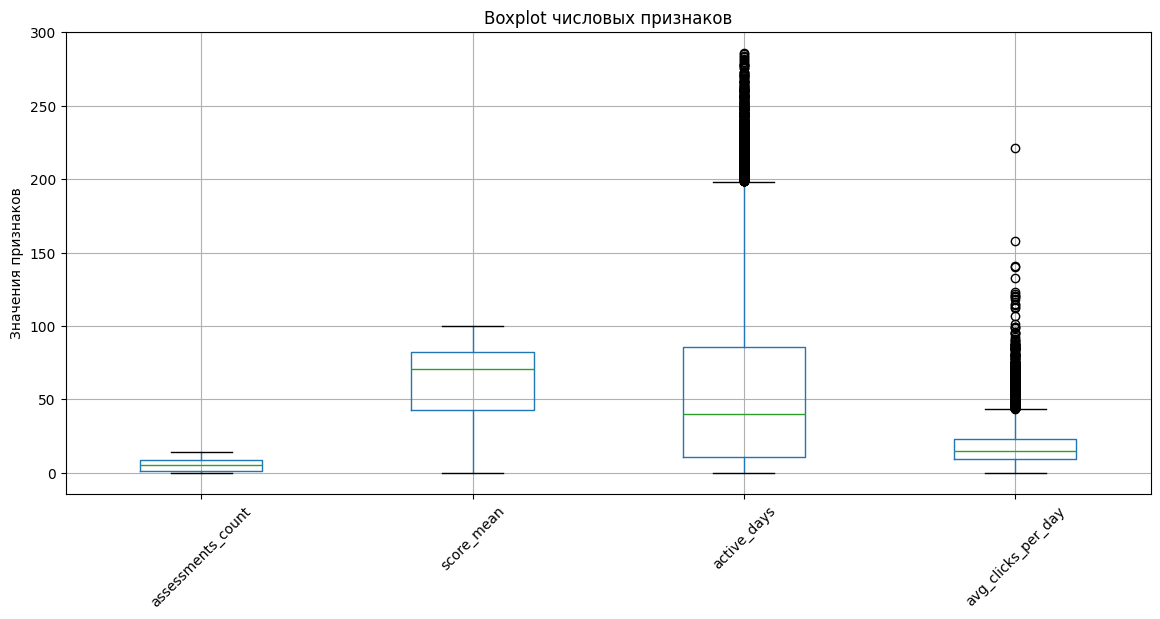

In [ ]:
num_cols_to_plot = [
    'assessments_count',
    'score_mean',
    'active_days',
    'avg_clicks_per_day'
]

plt.figure(figsize=(14, 6))
base_df[num_cols_to_plot].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot числовых признаков")
plt.ylabel("Значения признаков")
plt.grid(True)
plt.show()

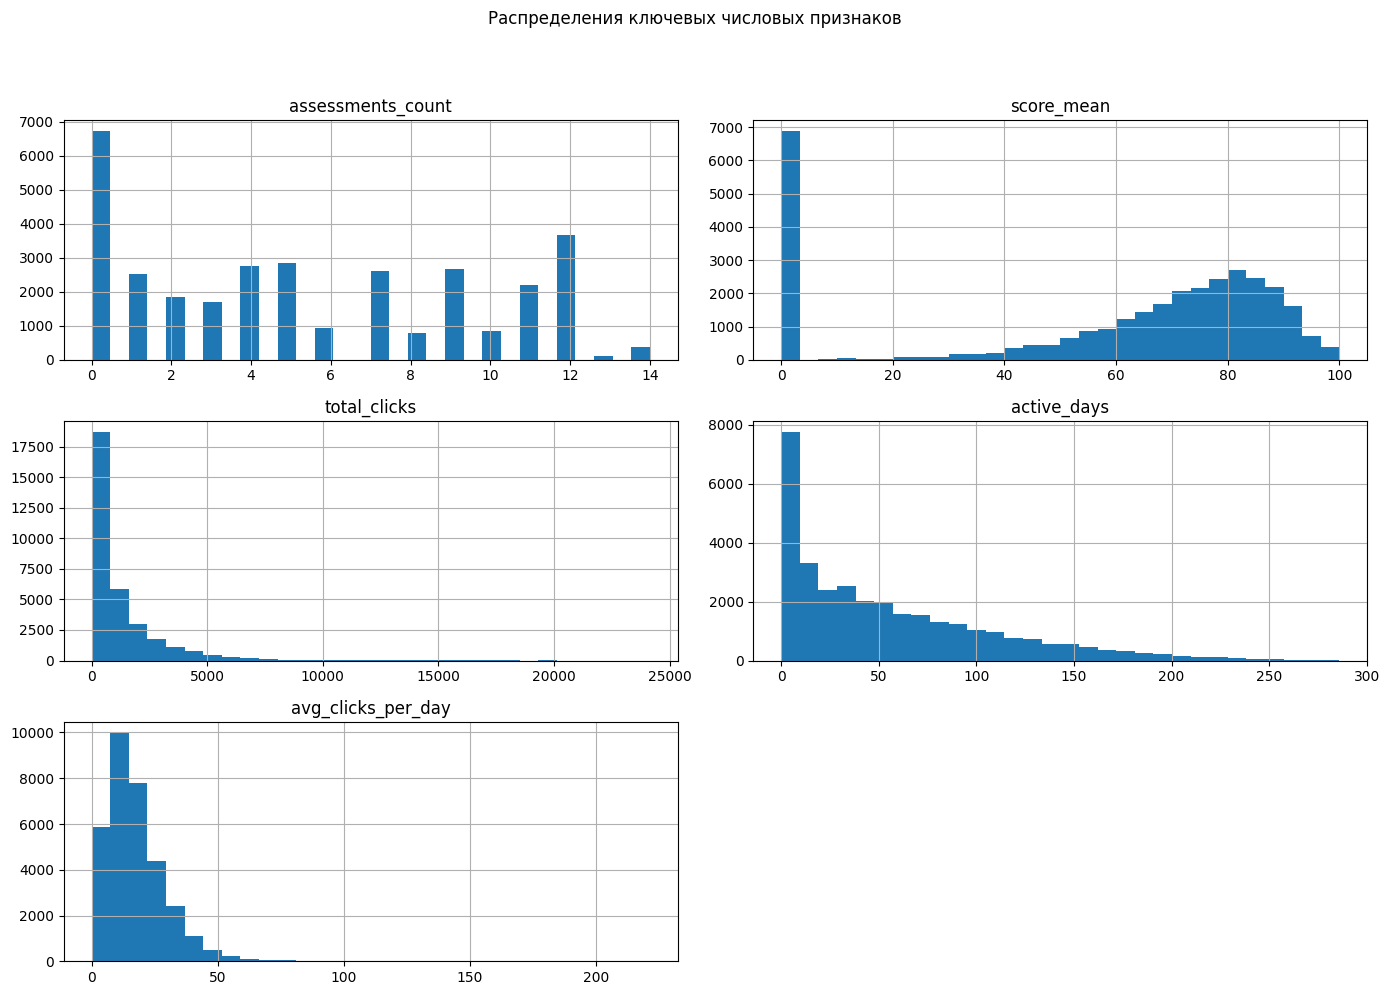

In [ ]:
num_cols_to_plot = [
    'assessments_count',
    'score_mean',
    'total_clicks',
    'active_days',
    'avg_clicks_per_day'
]

base_df[num_cols_to_plot].hist(figsize=(14, 10), bins=30)
plt.suptitle("Распределения ключевых числовых признаков", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### 5.5. Визуализация распределения ключевых признаков по группам риска

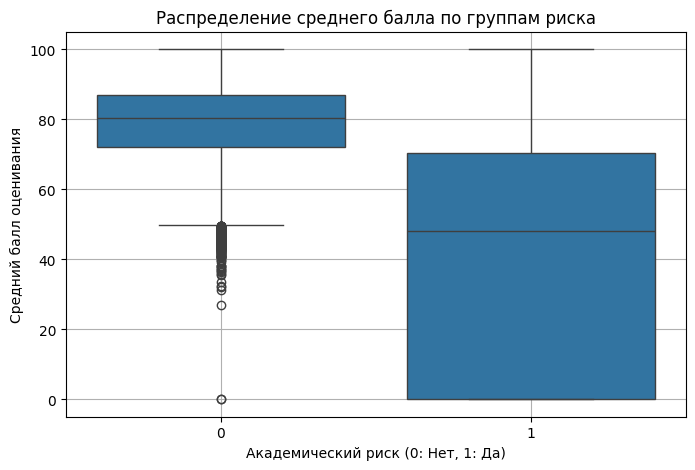

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=base_df, x='at_risk', y='score_mean')
plt.title("Распределение среднего балла по группам риска")
plt.xlabel("Академический риск (0: Нет, 1: Да)")
plt.ylabel("Средний балл оценивания")
plt.grid(True)
plt.show()

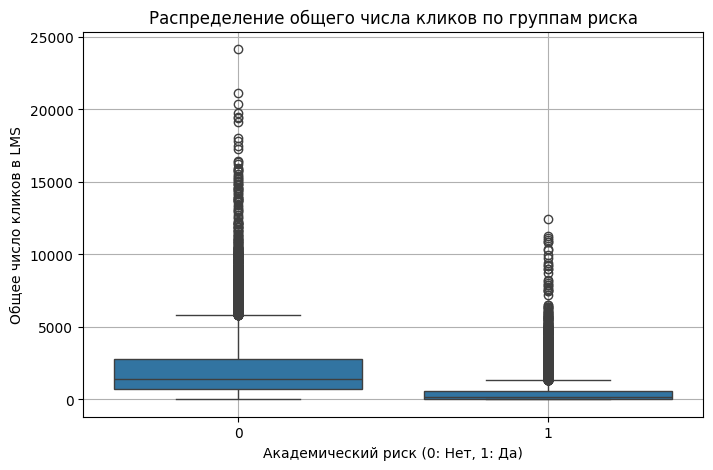

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=base_df, x='at_risk', y='total_clicks')
plt.title("Распределение общего числа кликов по группам риска")
plt.xlabel("Академический риск (0: Нет, 1: Да)")
plt.ylabel("Общее число кликов в LMS")
plt.grid(True)
plt.show()

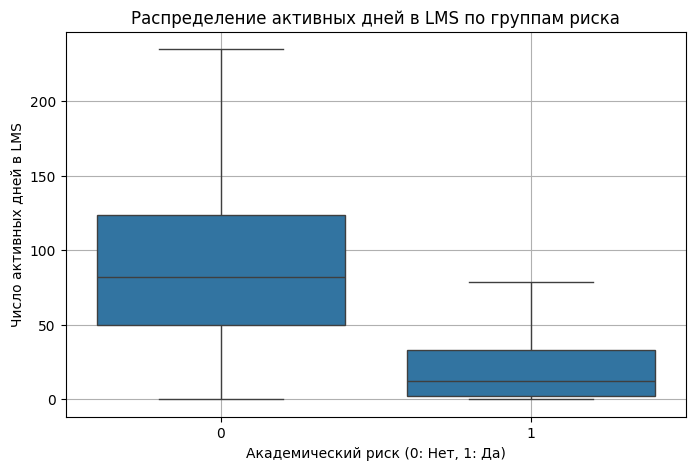

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=base_df, x='at_risk', y='active_days', showfliers=False)
plt.title("Распределение активных дней в LMS по группам риска")
plt.xlabel("Академический риск (0: Нет, 1: Да)")
plt.ylabel("Число активных дней в LMS")
plt.grid(True)
plt.show()

In [ ]:
categorical_cols = [
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'disability'
]

numeric_cols = [
    'num_of_prev_attempts',
    'studied_credits',
    'date_registration',
    'assessments_count',
    'score_mean',
    'score_median',
    'score_max',
    'score_min',
    'banked_share',
    'total_clicks',
    'active_days',
    'avg_clicks_per_day'
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """Вычисляет и выводит основные метрики классификации."""
    print(f"--- Оценка производительности {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
    if y_proba is not None:
        print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print("\nОтчет о классификации:\n", classification_report(y_true, y_pred))


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

## 7. Моделирование: Логистическая регрессия

Для первой модели используется логистическая регрессия. Создается пайплайн для автоматической предобработки данных (OneHotEncoding для категориальных признаков и StandardScaler для числовых) и обучения модели.

In [ ]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

In [ ]:
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'region',
                                                   'highest_education',
                                                   'imd_band', 'age_band',
                                                   'disability']),
                                                 ('num', StandardScaler(),
                                                  ['num_of_prev_attempts',
                                                   'studied_credits',
                                                   'date_registration',
                                                   'assessments_count',
                                                   'score_mean', 'score_median',
                                                   'score_max', 'score_min',
                                                   'banked_share',
                                                   'total_clicks',
                                                   'active_days',
                                                   'avg_clicks_per_day'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [ ]:
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

### 7.1. Отчет о классификации и метрики

In [ ]:
evaluate_model(y_test, y_pred, y_proba, "Logistic Regression")

--- Оценка производительности Logistic Regression ---
Accuracy : 0.8833
Precision: 0.9010
Recall   : 0.8758
F1-score : 0.8882
ROC-AUC  : 0.9508

Отчет о классификации:
               precision    recall  f1-score   support

           0       0.86      0.89      0.88      3083
           1       0.90      0.88      0.89      3470

    accuracy                           0.88      6553
   macro avg       0.88      0.88      0.88      6553
weighted avg       0.88      0.88      0.88      6553



### 7.2. Матрица ошибок (Confusion Matrix)

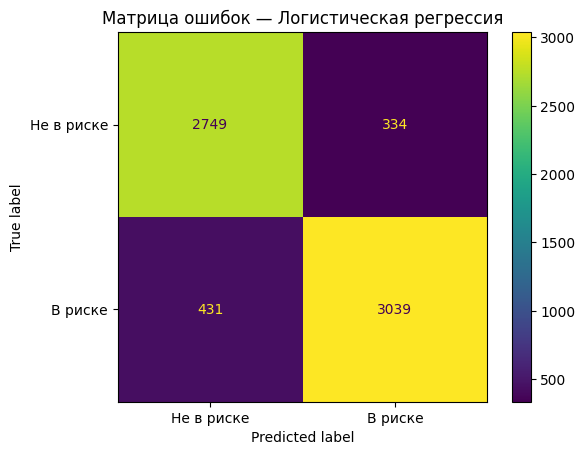

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не в риске', 'В риске'])
disp.plot()
plt.title("Матрица ошибок — Логистическая регрессия")
plt.show()

### 7.3. ROC-кривая

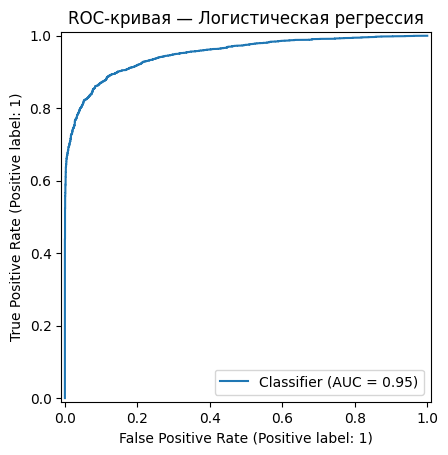

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC-кривая — Логистическая регрессия")
plt.show()

In [ ]:
feature_names = logreg_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
coefficients = logreg_pipeline.named_steps['model'].coef_[0]

### 7.4. Интерпретация модели: коэффициенты логистической регрессии

Коэффициенты модели используются для определения наиболее влиятельных признаков, связанных с академическим риском. Отрицательные значения уменьшают риск, положительные — увеличивают. Чем больше абсолютное значение, тем сильнее влияние признака.

In [ ]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

coef_df.sort_values('abs_coefficient', ascending=False).head(20)

,feature,coefficient,abs_coefficient
46,num__active_days,-1.532190,1.532190
40,num__score_mean,-1.499293,1.499293
39,num__assessments_count,-1.438627,1.438627
45,num__total_clicks,0.515168,0.515168
41,num__score_median,-0.503931,0.503931
42,num__score_max,-0.423088,0.423088
17,cat__highest_education_Lower Than A Level,0.413540,0.413540
18,cat__highest_education_No Formal quals,0.381840,0.381840
1,cat__gender_M,0.346494,0.346494
43,num__score_min,0.311006,0.311006


/tmp/ipykernel_28912/1686037185.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, x='coefficient', y='feature', palette='viridis')


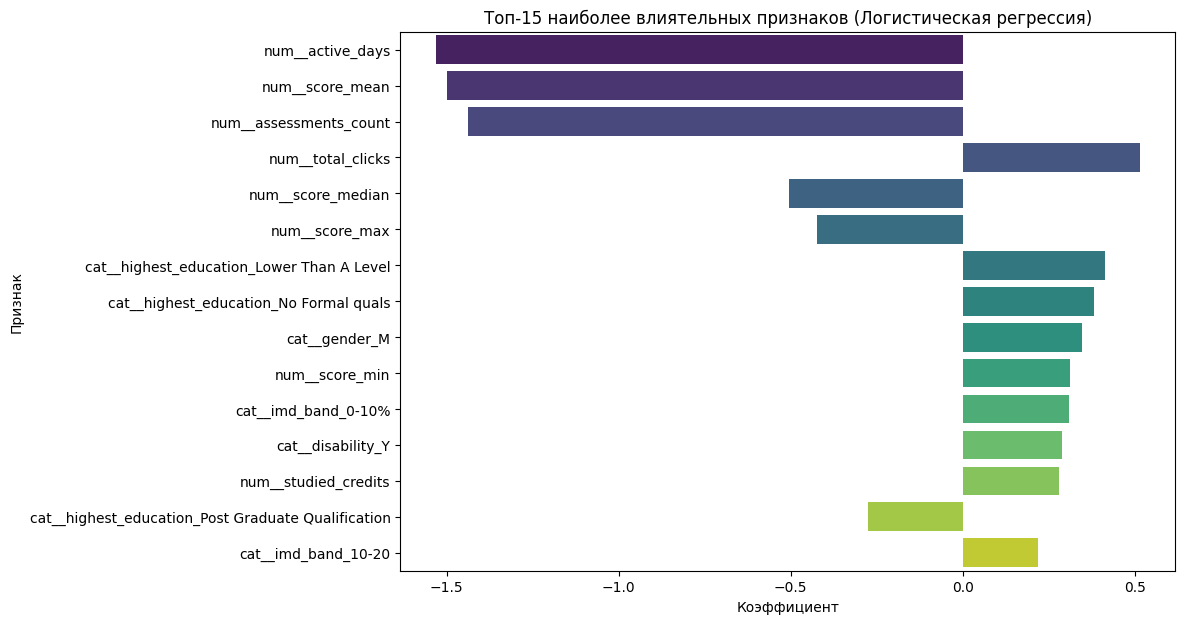

In [ ]:
top_coef = coef_df.sort_values('abs_coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_coef, x='coefficient', y='feature', palette='viridis')
plt.title("Топ-15 наиболее влиятельных признаков (Логистическая регрессия)")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.show()

### 7.5. Интерпретация модели: Permutation Importance

Permutation Importance используется для оценки того, насколько сильно производительность модели зависит от каждого признака. Признаки с высоким Permutation Importance при случайном перемешивании приводят к значительному падению качества модели. Этот метод отвечает на вопрос: 'Если случайно перемешать значения этого признака, насколько ухудшится качество модели?'

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
perm_result = permutation_importance(
    logreg_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

In [ ]:
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
})

perm_df = perm_df.sort_values('importance_mean', ascending=False)

perm_df.head(15)

,feature,importance_mean,importance_std
9,assessments_count,0.102775,0.004452
16,active_days,0.092460,0.004449
10,score_mean,0.055818,0.004082
11,score_median,0.006802,0.001144
13,score_min,0.005115,0.002098
12,score_max,0.004387,0.001355
15,total_clicks,0.004079,0.002388
7,studied_credits,0.002577,0.001192
2,highest_education,0.002490,0.001164
6,num_of_prev_attempts,0.001186,0.000776


/tmp/ipykernel_28912/476017848.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_perm, x='importance_mean', y='feature', palette='magma')


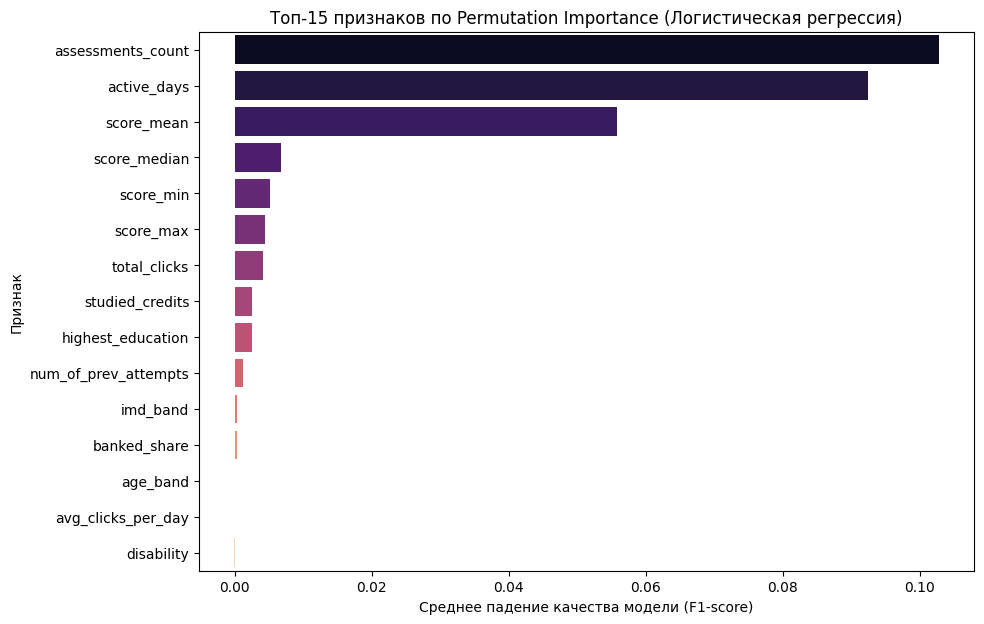

In [ ]:
top_perm = perm_df.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_perm, x='importance_mean', y='feature', palette='magma')
plt.title("Топ-15 признаков по Permutation Importance (Логистическая регрессия)")
plt.xlabel("Среднее падение качества модели (F1-score)")
plt.ylabel("Признак")
plt.show()

Результаты показывают, что регулярность активности и успешность оцениваний являются критически важными факторами для прогнозирования риска. В частности, метрики, связанные с активностью в LMS (например, `active_days`), и результаты оцениваний (`score_mean`, `assessments_count`) демонстрируют значительное влияние на предсказания модели. Это означает, что последовательные паттерны вовлеченности могут быть более информативными, чем короткие всплески активности.

## 8. Моделирование Random Forest

В качестве второй модели используется алгоритм Random Forest, известный своей способностью обрабатывать нелинейные зависимости и высокой производительностью. Аналогично, создается пайплайн для предобработки данных и обучения модели.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [ ]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'region',
                                                   'highest_education',
                                                   'imd_band', 'age_band',
                                                   'disability']),
                                                 ('num', 'passthrough',
                                                  ['num_of_prev_attempts',
                                                   'studied_credits',
                                                   'date_registration',
                                                   'assessments_count',
                                                   'score_mean', 'score_median',
                                                   'score_max', 'score_min',
                                                   'banked_share',
                                                   'total_clicks',
                                                   'active_days',
                                                   'avg_clicks_per_day'])])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

Метрики модели

In [ ]:
evaluate_model(y_test, rf_pred, rf_proba, "Random Forest")

--- Оценка производительности Random Forest ---
Accuracy : 0.8994
Precision: 0.9413
Recall   : 0.8640
F1-score : 0.9010
ROC-AUC  : 0.9648

Отчет о классификации:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90      3083
           1       0.94      0.86      0.90      3470

    accuracy                           0.90      6553
   macro avg       0.90      0.90      0.90      6553
weighted avg       0.90      0.90      0.90      6553



### 8.1. Матрица ошибок (Confusion Matrix)

### 8.2. ROC-кривая

In [ ]:
results = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    },
    {
        'model': 'Random Forest',
        'accuracy': accuracy_score(y_test, rf_pred),
        'precision': precision_score(y_test, rf_pred),
        'recall': recall_score(y_test, rf_pred),
        'f1': f1_score(y_test, rf_pred),
        'roc_auc': roc_auc_score(y_test, rf_proba)
    }
])

print("Таблица сравнения моделей:\n")
display(results.sort_values('roc_auc', ascending=False).round(4))

Таблица сравнения моделей:



,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.8994,0.9413,0.8640,0.9010,0.9648
0,Logistic Regression,0.8833,0.9010,0.8758,0.8882,0.9508


### 8.1. Матрица ошибок (Confusion Matrix)

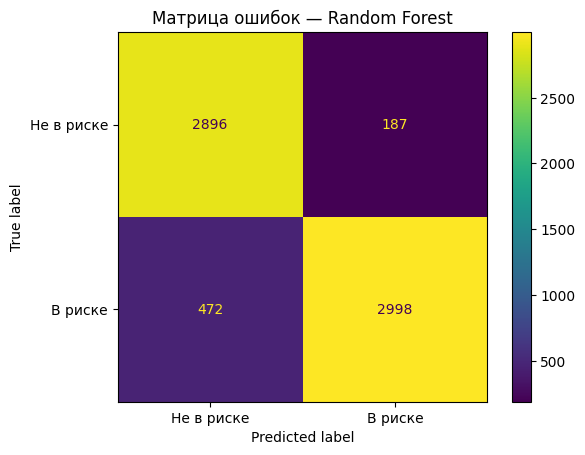

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Не в риске', 'В риске'])
disp_rf.plot()
plt.title("Матрица ошибок — Random Forest")
plt.show()

### 8.2. ROC-кривая

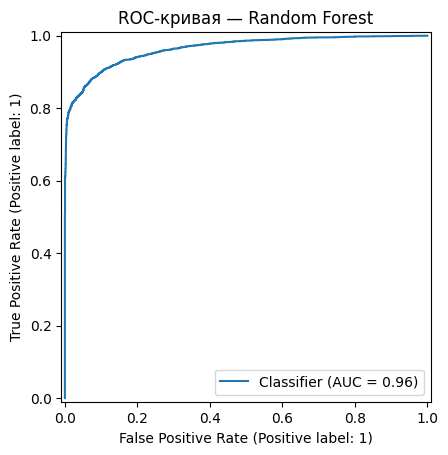

In [ ]:
RocCurveDisplay.from_predictions(y_test, rf_proba)
plt.title("ROC-кривая — Random Forest")
plt.show()

### 8.3. Важность признаков (Feature Importance) для Random Forest

Важность признаков для модели RF позволяет определить, какие факторы вносят наибольший вклад в предсказание академического риска.

In [ ]:
rf_feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
rf_importances = rf_pipeline.named_steps['model'].feature_importances_

In [ ]:
rf_importance_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

rf_importance_df.head(20)

,feature,importance
39,num__assessments_count,0.264776
46,num__active_days,0.136216
42,num__score_max,0.118533
45,num__total_clicks,0.094976
40,num__score_mean,0.087429
41,num__score_median,0.079727
43,num__score_min,0.069265
47,num__avg_clicks_per_day,0.043199
38,num__date_registration,0.020182
37,num__studied_credits,0.011867


/tmp/ipykernel_28912/1510945181.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rf, x='importance', y='feature', palette='cividis')


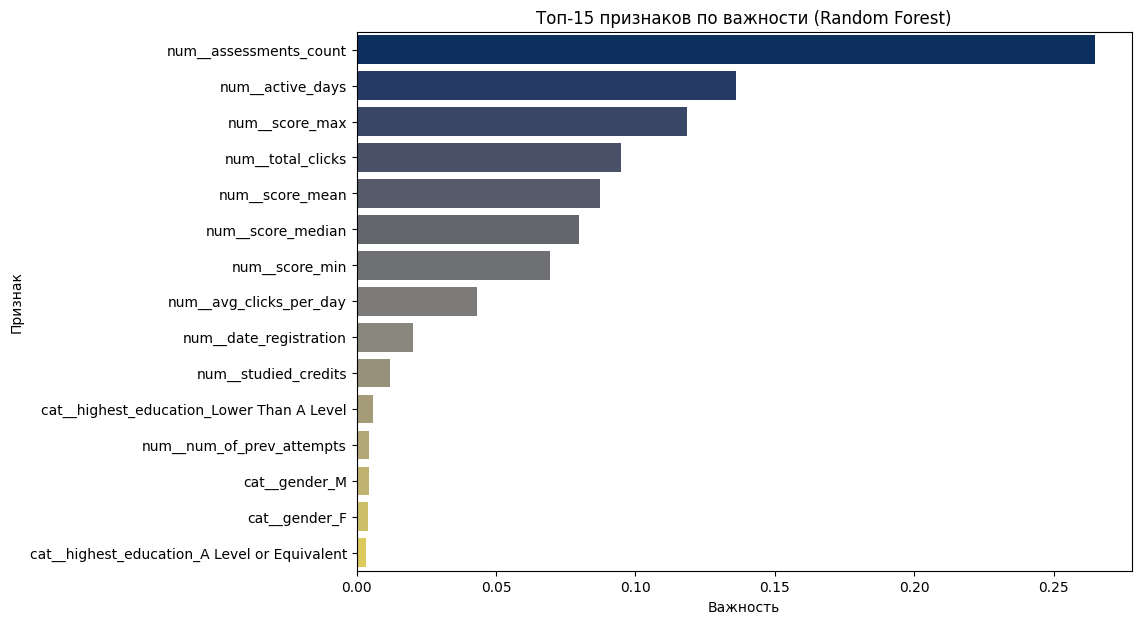

In [ ]:
top_rf = rf_importance_df.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_rf, x='importance', y='feature', palette='cividis')
plt.title("Топ-15 признаков по важности (Random Forest)")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

## 9. Сравнение моделей и выбор оптимальной стратегии

Сравнение метрик логистической регрессии и rf показывает, что Random Forest демонстрирует более высокую точность (`Accuracy`) и ROC-AUC. Однако, при выборе модели важно учитывать бизнес-цели.

**Приоритет задачи:** В контексте выявления академического риска, ключевой метрикой является `Recall` для класса '1' (студенты в риске). Высокий `Recall` означает, что модель эффективно находит большинство студентов, которые действительно находятся в группе риска, минимизируя количество ложноотрицательных прогнозов. Пропуск студента из группы риска может иметь серьезные негативные последствия.

- Random Forest реже ошибается, когда предсказывает 'риск' (выше Precision), но чуть чаще пропускает рисковых студентов (ниже Recall) по сравнению с логистической регрессией.
- Логистическая регрессия, хоть и имеет немного ниже общие метрики, показала конкурентный `Recall` для класса '1', что может быть предпочтительнее для данной задачи, если цель — не пропустить как можно больше рисковых студентов, даже ценой некоторых ложноположительных срабатываний.

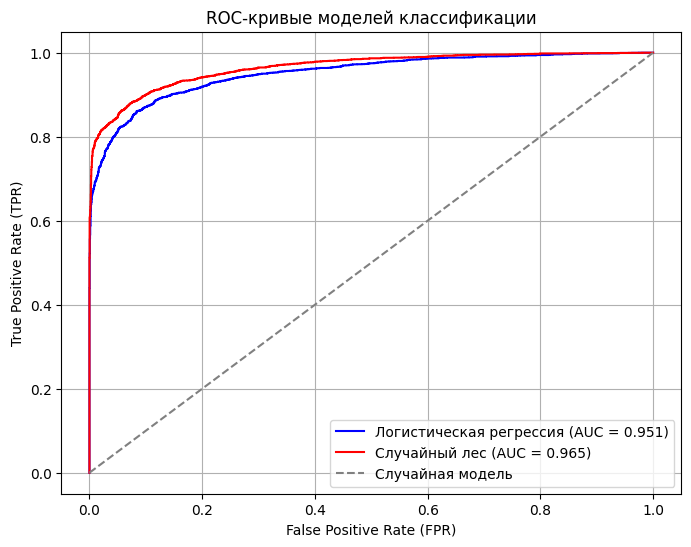

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые моделей классификации")
plt.legend()
plt.grid(True)
plt.show()

### Выводы по сравнению моделей:

- Если требуется максимально точный общий прогноз и баланс между Precision и Recall, предпочтителен Random Forest. RF достигает более сильной общей дискриминации классов.
- Если критически важно не пропустить студентов из группы риска (максимизация Recall для класса '1'), логистическая регрессия может быть более подходящим выбором благодаря своему балансу между обнаружением рисковых студентов и общей производительностью. Она также предоставляет более прозрачную интерпретацию влияния признаков и остается конкурентоспособной.

## 10. Финальные выводы и дальнейшие шаги

### 10.1. Сводная таблица производительности моделей

| Model               | Accuracy | Precision | Recall | F1     | ROC-AUC |
|---------------------|----------|-----------|--------|--------|---------|
| Random Forest       | 0.8994   | 0.9413    | 0.8640 | 0.9010 | 0.9648  |
| Logistic Regression | 0.8833   | 0.9010    | 0.8758 | 0.8882 | 0.9508  |

### 10.2. Финальный вывод (Conclusion)

- Проект демонстрирует полный ML-рабочий процесс для прогнозирования академического риска на основе демографических данных студентов, успеваемости по оцениваниям и активности в LMS.
- Среди протестированных моделей, Random Forest показал наилучшую общую предсказательную способность (более высокий ROC-AUC и F1-score), тогда как Логистическая регрессия обеспечила более прозрачную интерпретацию влияния признаков.
- Наиболее информативными признаками оказались количество выполненных оцениваний, средний балл по оцениваниям и регулярность взаимодействия с LMS.
- Этот анализ подчеркивает важность использования поведенческих и оценочных данных для раннего выявления студентов в группе риска, что позволяет своевременно применять меры поддержки и повышать удержание студентов.

### 10.3. Ограничения (Limitations)

- Агрегированные признаки, построенные на основе всего доступного периода обучения, могут содержать информацию, которая не была бы доступна при реальном сценарии раннего прогнозирования. Это может приводить к утечке информации (information leakage).
- Для создания системы раннего предупреждения, признаки должны быть ограничены только информацией, доступной к определенному моменту времени в течение курса.
- Дальнейшая оптимизация порога классификации может потребоваться для точного баланса между Precision и Recall в зависимости от конкретных бизнес-требований.

### 10.4. Следующие шаги и улучшения (Next Steps)

- Разработать версию модели для раннего предупреждения, используя признаки только из первых нескольких недель активности студентов.
- Протестировать более сложные ансамблевые модели, такие как градиентный бустинг (например, LightGBM, XGBoost), для потенциального повышения производительности.
- Провести тщательную настройку гиперпараметров моделей с использованием кросс-валидации для оптимизации производительности.
- Реализовать выбор оптимального порога классификации с учетом компромисса между Precision и Recall, исходя из стоимости ошибок.
- Инкапсулировать процессы предобработки данных и инференса модели в переиспользуемый пайплайн для упрощения развертывания и масштабирования.